In [29]:
import time
import matplotlib.pyplot as plt

from motion_planning.pdg import PDG
from motion_planning.space import PointRobot
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.database import generate_database

from motion_planning.circle_approximation import ApproximationSpace

# Setup Base Robot & Environment

In [30]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Setup Approximation Environment

In [31]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

# Generate Path Database

In [32]:
db_save_path = '../saves/pdg_example_database.pickle'
db = generate_database(db_save_path)
pdg = PDG(env, db_save_path)

Connecting Edges Using knn strategy
Env 1, Task 1
Adding Nodes, Current Size: 799
Connecting Edges Using knn strategy
Num Times Extended: 1
Env 1, Task 2
Num Times Extended: 0
Env 1, Task 3
Num Times Extended: 0
Env 1, Task 4
Num Times Extended: 0
Env 1, Task 5
Num Times Extended: 0
Env 1, Task 6
Num Times Extended: 0
Env 1, Task 7
Num Times Extended: 0
Env 1, Task 8
Num Times Extended: 0
Env 1, Task 9
Num Times Extended: 0
Env 1, Task 10
Num Times Extended: 0
Env 1, Task 11
Num Times Extended: 0
Env 1, Task 12
Num Times Extended: 0
Env 1, Task 13
Num Times Extended: 0
Env 1, Task 14
Num Times Extended: 0
Env 1, Task 15
Num Times Extended: 0
Env 1, Task 16
Num Times Extended: 0
Env 1, Task 17
Num Times Extended: 0
Env 1, Task 18
Num Times Extended: 0
Env 1, Task 19
Num Times Extended: 0
Env 1, Task 20
Num Times Extended: 0
DB Size: 20
Connecting Edges Using knn strategy
Env 2, Task 1
Num Times Extended: 0
Env 2, Task 2
Adding Nodes, Current Size: 818
Connecting Edges Using knn strategy

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


Num Times Extended: 1
Env 2, Task 3
Num Times Extended: 0
Env 2, Task 4
Num Times Extended: 0
Env 2, Task 5
Num Times Extended: 0
Env 2, Task 6
Num Times Extended: 0
Env 2, Task 7
Num Times Extended: 0
Env 2, Task 8
Num Times Extended: 0
Env 2, Task 9
Num Times Extended: 0
Env 2, Task 10
Num Times Extended: 0
Env 2, Task 11
Num Times Extended: 0
Env 2, Task 12
Num Times Extended: 0
Env 2, Task 13
Num Times Extended: 0
Env 2, Task 14
Num Times Extended: 0
Env 2, Task 15
Num Times Extended: 0
Env 2, Task 16
Num Times Extended: 0
Env 2, Task 17
Num Times Extended: 0
Env 2, Task 18
Num Times Extended: 0
Env 2, Task 19
Num Times Extended: 0
Env 2, Task 20
Num Times Extended: 0
DB Size: 40
Saving Database to ../saves/pdg_example_database.pickle


# Create Task to Solve

In [39]:
start, target = env.space.sample_task()

# Compute Path for Guidance for Given Task

In [40]:
start_time = time.time()
pdg.compute_retained_paths(target)
end_time = time.time()
print(f"Time to compute paths: {end_time-start_time}")

Number of Paths to Start with: 1
Time to compute paths: 0.004846096038818359


# Search for Path

In [41]:
start_time = time.time()
path = pdg.search(start, target)
end_time = time.time()
print(f"Time to search: {end_time - start_time}", len(path))

Found Path in 0 iterations
Time to search: 0.003247976303100586 25


# Draw Search Tree

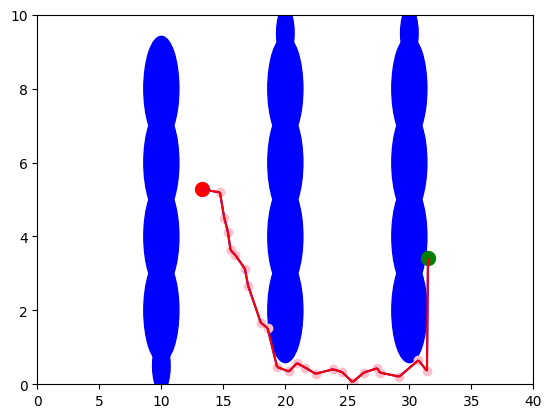

In [42]:
pdg.draw_tree(plt.gca(), path)
plt.show()